Loading the dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/Colab Notebooks/chest_pneumonia.zip" -d "/content/"


In [ ]:
import os

print(os.listdir("/content/chest_xray/chest_xray"))

['train', 'val', '.DS_Store', 'test']


In [ ]:

print(os.listdir("/content/chest_xray/train"))


['NORMAL', 'PNEUMONIA']


In [ ]:
train_dir = "/content/chest_xray/chest_xray/train"
test_dir = "/content/chest_xray/chest_xray/test"
val_dir = "/content/chest_xray/chest_xray/val"

Data Preprocessing

In [ ]:
from torchvision import datasets, transforms



In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

In [ ]:
print(train_dataset.classes)
print(train_dataset.class_to_idx)

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

5216
16
624


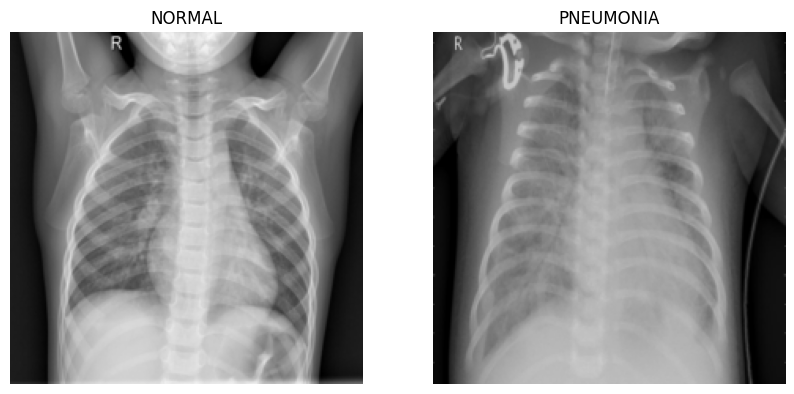

In [ ]:
import torch
import matplotlib.pyplot as plt

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

normal_img = None
pneumonia_img = None

for img, label in train_dataset:
    if label == 0 and normal_img is None:
        normal_img = img
    elif label == 1 and pneumonia_img is None:
        pneumonia_img = img

    if normal_img is not None and pneumonia_img is not None:
        break

# 3. Plot the denormalized images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(denormalize(normal_img).permute(1, 2, 0))
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(denormalize(pneumonia_img).permute(1, 2, 0))
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

In [ ]:
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


In [ ]:
img, label = train_dataset[0]

print(img.shape)

torch.Size([3, 224, 224])


Feature Extraction

In [ ]:
model.fc = nn.Linear(2048, 2)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


Evaluation

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # ---------- Training ----------
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total

    # ---------- Validation ----------
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Training Loss : {running_loss / len(train_loader):.4f}")
    print(f"Training Accuracy : {train_accuracy:.2f}%")
    print(f"Validation Accuracy : {val_accuracy:.2f}%")
    print("-" * 40)

Epoch 1/10
Training Loss : 0.3233
Training Accuracy : 86.64%
Validation Accuracy : 56.25%
----------------------------------------
Epoch 2/10
Training Loss : 0.1841
Training Accuracy : 93.75%
Validation Accuracy : 62.50%
----------------------------------------
Epoch 3/10
Training Loss : 0.1542
Training Accuracy : 94.73%
Validation Accuracy : 62.50%
----------------------------------------
Epoch 4/10
Training Loss : 0.1341
Training Accuracy : 95.09%
Validation Accuracy : 62.50%
----------------------------------------
Epoch 5/10
Training Loss : 0.1234
Training Accuracy : 95.38%
Validation Accuracy : 62.50%
----------------------------------------
Epoch 6/10
Training Loss : 0.1170
Training Accuracy : 95.94%
Validation Accuracy : 62.50%
----------------------------------------
Epoch 7/10
Training Loss : 0.1064
Training Accuracy : 96.49%
Validation Accuracy : 62.50%
----------------------------------------
Epoch 8/10
Training Loss : 0.0998
Training Accuracy : 96.32%
Validation Accuracy : 

In [ ]:
model.eval()

test_correct = 0
test_total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)

        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * test_correct / test_total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 83.65%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

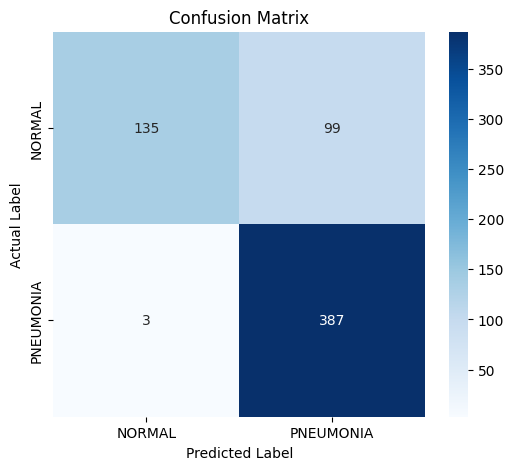

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      NORMAL       0.98      0.58      0.73       234
   PNEUMONIA       0.80      0.99      0.88       390

    accuracy                           0.84       624
   macro avg       0.89      0.78      0.80       624
weighted avg       0.86      0.84      0.82       624



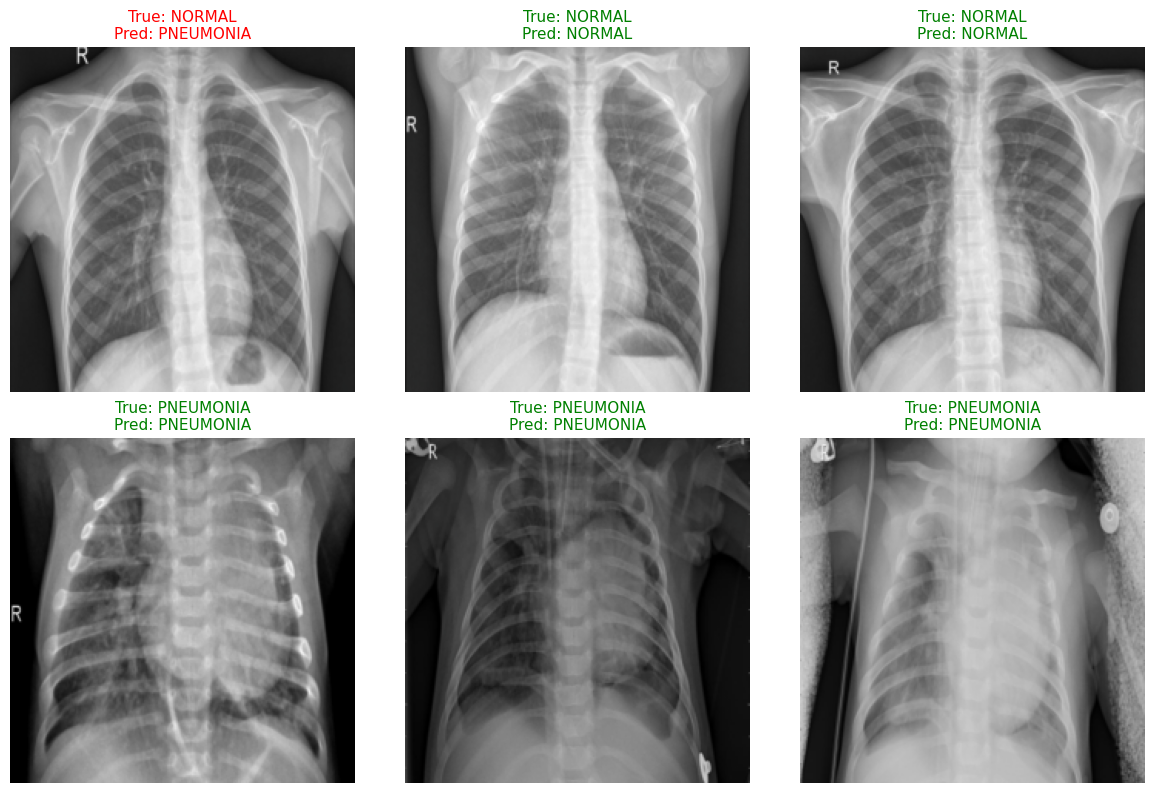

In [ ]:
model.eval()

normal_images = []
normal_labels = []

pneumonia_images = []
pneumonia_labels = []

# Collect 3 NORMAL and 3 PNEUMONIA images
for image, label in test_dataset:

    if label == 0 and len(normal_images) < 3:
        normal_images.append(image)
        normal_labels.append(label)

    elif label == 1 and len(pneumonia_images) < 3:
        pneumonia_images.append(image)
        pneumonia_labels.append(label)

    if len(normal_images) == 3 and len(pneumonia_images) == 3:
        break

images = normal_images + pneumonia_images
labels = normal_labels + pneumonia_labels

images_tensor = torch.stack(images).to(device)

with torch.no_grad():
    outputs = model(images_tensor)
    _, predicted = torch.max(outputs, 1)

predicted = predicted.cpu()

plt.figure(figsize=(12, 8))

for i in range(6):

    plt.subplot(2, 3, i + 1)

    # FIX: Denormalize image before permuting for display
    img_to_show = denormalize(images[i]).permute(1, 2, 0)
    plt.imshow(img_to_show)

    true_label = train_dataset.classes[labels[i]]
    pred_label = train_dataset.classes[predicted[i]]

    title_color = "green" if true_label == pred_label else "red"

    plt.title(
        f"True: {true_label}\nPred: {pred_label}",
        color=title_color,
        fontsize=11
    )

    plt.axis("off")

plt.tight_layout()
plt.show()